### Content-Based Recommendation System
Hệ khuyến nghị game dựa trên nội dung, sử dụng dữ liệu từ MySQL view `vw_recommendation_full`.

Hệ thống sử dụng:
- `short_description`
- `genres`
- `developers`
- `publishers`

để tạo nội dung tổng hợp cho từng game, sau đó áp dụng TF-IDF và Cosine Similarity để tìm các game tương tự.

#### Ví dụ
- Người dùng nhập: `Counter-Strike`
- Hệ thống tìm các game có nội dung, thể loại, nhà phát triển hoặc nhà phát hành tương tự
- Trả về top game có độ tương đồng cao nhất

In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

#### 1. Load Dataset

In [ ]:
sys.path.append(os.path.abspath(".."))

from src.db_connection import get_engine
engine = get_engine()
df_rec = pd.read_sql("""SELECT * FROM vw_recommendation_full""", engine)
print(df_rec.shape)
df_rec.head()

(224170, 7)


,appid,name,type,short_description,genres,developers,publishers
0,10,Counter-Strike,game,Play the world's number 1 online action game. ...,Action,Valve,Valve
1,20,Team Fortress Classic,game,One of the most popular online action games of...,Action,Valve,Valve
2,30,Day of Defeat,game,Enlist in an intense brand of Axis vs. Allied ...,Action,Valve,Valve
3,40,Deathmatch Classic,game,Enjoy fast-paced multiplayer gaming with Death...,Action,Valve,Valve
4,50,Half-Life: Opposing Force,game,Return to the Black Mesa Research Facility as ...,Action,Gearbox Software,Valve


#### 2. Lọc dữ liệu chỉ lấy game

Một số bản ghi trong Steam có thể là DLC, soundtrack, video hoặc nội dung phụ.  
Để hệ khuyến nghị trả về kết quả hợp lý hơn, nhóm chỉ giữ lại các bản ghi có `type = game`.

In [14]:
df_rec = df_rec[
    df_rec["type"].str.lower() == "game"
].copy()

df_rec = df_rec.dropna(
    subset=["name", "short_description"])

df_rec.reset_index(drop=True, inplace=True)
print(df_rec.shape)
df_rec.head()

(142628, 7)


,appid,name,type,short_description,genres,developers,publishers
0,10,Counter-Strike,game,Play the world's number 1 online action game. ...,Action,Valve,Valve
1,20,Team Fortress Classic,game,One of the most popular online action games of...,Action,Valve,Valve
2,30,Day of Defeat,game,Enlist in an intense brand of Axis vs. Allied ...,Action,Valve,Valve
3,40,Deathmatch Classic,game,Enjoy fast-paced multiplayer gaming with Death...,Action,Valve,Valve
4,50,Half-Life: Opposing Force,game,Return to the Black Mesa Research Facility as ...,Action,Gearbox Software,Valve


#### 3. Tạo cột `content`

Cột `content` được tạo bằng cách kết hợp mô tả ngắn, thể loại, nhà phát triển và nhà phát hành.  
Việc này giúp hệ khuyến nghị khai thác nhiều thông tin hơn thay vì chỉ dựa vào mô tả game.

In [15]:
df_rec["content"] = (
    df_rec["short_description"].fillna("") + " " +
    df_rec["genres"].fillna("") + " " +
    df_rec["developers"].fillna("") + " " +
    df_rec["publishers"].fillna("")
)

df_rec[[ 
    "name",
    "type",
    "short_description",
    "genres",
    "developers",
    "publishers",
    "content"
]].head()

,name,type,short_description,genres,developers,publishers,content
0,Counter-Strike,game,Play the world's number 1 online action game. ...,Action,Valve,Valve,Play the world's number 1 online action game. ...
1,Team Fortress Classic,game,One of the most popular online action games of...,Action,Valve,Valve,One of the most popular online action games of...
2,Day of Defeat,game,Enlist in an intense brand of Axis vs. Allied ...,Action,Valve,Valve,Enlist in an intense brand of Axis vs. Allied ...
3,Deathmatch Classic,game,Enjoy fast-paced multiplayer gaming with Death...,Action,Valve,Valve,Enjoy fast-paced multiplayer gaming with Death...
4,Half-Life: Opposing Force,game,Return to the Black Mesa Research Facility as ...,Action,Gearbox Software,Valve,Return to the Black Mesa Research Facility as ...


#### 4. Clean text
Làm sạch trực tiếp cột `content`.  
Điều này giúp thống nhất với bước TF-IDF, vì TF-IDF sẽ được fit trên chính cột `content`.

In [5]:
df_rec["content"] = (
    df_rec["content"]
    .str.lower()
    .str.replace(r"<.*?>", " ", regex=True)
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_rec[["name", "content"]].head()

,name,content
0,Counter-Strike,play the world s number 1 online action game e...
1,Team Fortress Classic,one of the most popular online action games of...
2,Day of Defeat,enlist in an intense brand of axis vs allied t...
3,Deathmatch Classic,enjoy fast paced multiplayer gaming with death...
4,Half-Life: Opposing Force,return to the black mesa research facility as ...


#### 5. TF-IDF Vectorization

In [16]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df_rec["content"])

print(tfidf_matrix.shape)

(142628, 5000)


#### 6. Cosine Similarity

Hệ thống recommendation sử dụng Cosine Similarity để đo mức độ tương đồng giữa các vector TF-IDF.

- Giá trị càng gần 1 → hai game càng giống nhau
- Giá trị càng gần 0 → hai game càng khác nhau

Do dataset lớn, nhóm không tính toàn bộ ma trận similarity. Thay vào đó, similarity được tính động cho từng game được truy vấn bằng `linear_kernel()`.

#### 7. Hàm recommendation

In [7]:
def recommend_games(game_name, top_n=5):
    matched_games = df_rec[
        df_rec["name"].str.contains(
            game_name,
            case=False,
            na=False,
            regex=False
        )
    ]

    if matched_games.empty:
        return f"Không tìm thấy game: {game_name}"

    idx = matched_games.index[0]

    cosine_scores = linear_kernel(
        tfidf_matrix[idx:idx + 1],
        tfidf_matrix
    ).flatten()

    similar_indices = cosine_scores.argsort()[-top_n - 1:-1][::-1]

    recommendations = df_rec.iloc[similar_indices][
        ["name", "type", "genres", "developers", "publishers"]
    ].copy()

    recommendations["similarity_score"] = cosine_scores[similar_indices]

    return recommendations

#### 8. Test hệ khuyến nghị

In [8]:
result_counter_strike = recommend_games("Counter-Strike", top_n=5)

result_counter_strike

,name,type,genres,developers,publishers,similarity_score
46916,Deadlock,game,Action,Valve,Valve,0.433392
1,Team Fortress Classic,game,Action,Valve,Valve,0.424233
12,Day of Defeat: Source,game,Action,Valve,Valve,0.407682
24,Alien Swarm,game,"Action, Free To Play",Valve,Valve,0.380453
32393,Are you ready for Valve Index?,game,NaN,Valve,NaN,0.370648


In [17]:
result_black_myth = recommend_games("Black Myth", top_n=5)
result_black_myth

,name,type,genres,developers,publishers,similarity_score
25517,Science Simulator,game,"Adventure, Casual, Early Access, Indie, Racing...",Callum Sales,NaN,0.337812
114510,Black Myth: Wukong Benchmark Tool,game,"Free To Play, Utilities",Game Science,Game Science,0.327304
55628,Cyborpunk Crisis,game,Action,PastureSoft,PastureSoft,0.323479
68041,GENIUS VS ANTICHRIST 1,game,"Adventure, Indie, RPG",WFG STUDIO,WFG STUDIO,0.304920
28607,Starquake Academy,game,"Adventure, Indie, Simulation",Lux Science,Lux Science,0.286230


In [18]:
result_gta = recommend_games("Grand Theft Auto", top_n=5)
result_gta

,name,type,genres,developers,publishers,similarity_score
49149,Worst Nightmare,game,"Adventure, Indie",Marca59,Marca59,0.383209
73011,Northern Kingdoms,game,"Casual, Early Access, Indie, Strategy",North Gold Studios,North Gold Studios,0.280311
103577,CubeGod,game,"Casual, Indie, Simulation",Toller Games,Toller Games,0.263320
56838,Selene's Nightmare,game,"Action, Adventure, Indie",HV,HV,0.260147
99575,Swashbuckler's Xmas,game,Action,North Shore Games,North Shore Games,0.251325


In [11]:
result_cyberpunk = recommend_games("Cyberpunk", top_n=5)

result_cyberpunk

,name,type,genres,developers,publishers,similarity_score
56437,Orakyubu,game,"Free To Play, Indie",Peter Lavigne,Peter Lavigne,0.483159
37233,Unitied,game,"Casual, Indie, Strategy",Peter Hijma,Peter Hijma,0.429905
43632,Thrust Legend,game,"Action, Indie",Peter Klauser,Peter Klauser,0.425660
113355,Two Broken Mirrors,game,"Action, Adventure, Indie","Hans-Peter Eriksson, Malin Hultman",Hans-Peter Eriksson,0.414569
94738,Polybius Invaders 2,game,"Action, Adventure, Casual","Jonni The Dodger, Peter Ward",Jonni The Dodger,0.397610


In [19]:
result_pubg = recommend_games("PUBG", top_n=5)
result_pubg

,name,type,genres,developers,publishers,similarity_score
35588,The Lost Island:Battle Royale,game,"Free To Play, Indie, Massively Multiplayer",Mohammad Muwafi,Mohammad Muwafi,0.398169
132140,IndianOps,game,"Action, Adventure, Free To Play, Indie, Massiv...",Deepak,iamsince1998,0.380547
89046,Worldwide Battle Royale,game,"Action, Adventure, Casual, Free To Play, Massi...",VR Byen,VR Byen,0.376432
31013,凯旋岛,game,"Action, Adventure, Free To Play, Massively Mul...",清风,清风,0.370643
112875,刀剑神魔录,game,"Action, Adventure, Free To Play, Massively Mul...",终风互娱,终风互娱,0.352076


#### 9. Visualization Recommendation Similarity

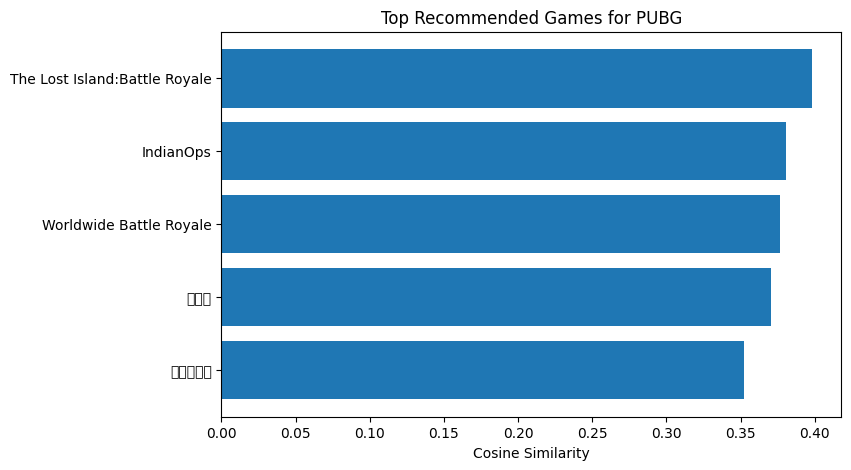

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    result_pubg["name"],
    result_pubg["similarity_score"]
)

plt.xlabel("Cosine Similarity")
plt.title("Top Recommended Games for PUBG")

plt.gca().invert_yaxis()
plt.show()

#### 10. Hạn chế của hệ thống

- Hệ thống chỉ sử dụng thông tin nội dung và metadata của game.
- Chưa sử dụng hành vi người dùng như rating, lịch sử chơi hoặc lịch sử mua.
- Chưa cá nhân hóa recommendation theo từng user.
- Chưa áp dụng Collaborative Filtering.
- Kết quả phụ thuộc vào chất lượng của `short_description`, `genres`, `developers` và `publishers`.

#### 11. Final Conclusion

Nhóm đã xây dựng hệ khuyến nghị game dựa trên nội dung (**Content-Based Recommendation System**) bằng cách kết hợp thông tin mô tả game, thể loại, nhà phát triển và nhà phát hành.

Quy trình thực hiện gồm:

- Lấy dữ liệu từ MySQL view `vw_recommendation_full`.
- Lọc dữ liệu để chỉ giữ lại các bản ghi có `type = game`.
- Tạo cột `content` từ `short_description`, `genres`, `developers` và `publishers`.
- Làm sạch trực tiếp cột `content`.
- Sử dụng TF-IDF để vector hóa nội dung game.
- Tính độ tương đồng bằng Cosine Similarity thông qua `linear_kernel()`.
- Trả về top game có nội dung tương tự với game được truy vấn.

Do dataset có kích thước lớn, nhóm không tính toàn bộ ma trận similarity để tránh vượt quá giới hạn bộ nhớ. Thay vào đó, hệ thống tính similarity động cho từng truy vấn, giúp tiết kiệm bộ nhớ và phù hợp hơn với dữ liệu lớn.

Nhóm cũng thử nghiệm hệ khuyến nghị với nhiều game khác nhau như `Counter-Strike`, `Black Myth`, `Grand Theft Auto`, `Cyberpunk` và `PUBG` để kiểm tra khả năng hoạt động trên nhiều thể loại game phổ biến.

Hệ thống hiện tại phù hợp với bài toán recommendation khi chưa có dữ liệu hành vi người dùng. Trong tương lai, có thể mở rộng bằng Collaborative Filtering hoặc Hybrid Recommendation System để cá nhân hóa kết quả tốt hơn.